In [4]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re
from tqdm import tqdm

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/controller_sweep/"
out_path = os.path.join(path, "combined_sweep.h5")
collate=True

In [5]:
if collate:
    def _parse_folder(folder_name):
        """
        Extract kp, kd, ki from folder names like:
        kp25.0_kd100.0_ki0.10
        """
        m = re.search(r"^kp([^_]+)_kd([^_]+)_ki([^_]+)$", folder_name)
        if m:
            try:
                return (
                    float(m.group(1)),  # kp
                    float(m.group(2)),  # kd
                    float(m.group(3)),  # ki
                )
            except ValueError:
                pass
        return -1.0, -1.0, -1.0

    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("kp")
    ]

    # Sort hierarchically by kp, then kd, then ki
    sweep_dirs.sort(key=lambda d: _parse_folder(d))

    out_path = os.path.join(path, "combined_dt_sweep.h5")
    missing = []

    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")

    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            kp, kd, ki = _parse_folder(folder)

            if kp < 0:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue

            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] kp={kp}, kd={kd}, ki={ki} — mirror_states.h5 not found")
                missing.append(folder)
                continue

            # Create a unique group name for this configuration
            group_name = f"kp_{kp:.6g}_kd_{kd:.6g}_ki_{ki:.6g}"

            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)

                # Copy everything from the source file root into the new group
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)

    print(f"\nSaved combined file → {out_path}")

    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")

Collating 62 folders into ../results/controller_sweep/combined_dt_sweep.h5...


 97%|█████████▋| 60/62 [21:50<00:41, 20.99s/it]

  [SKIP] kp=100.0, kd=500.0, ki=0.1 — mirror_states.h5 not found


100%|██████████| 62/62 [22:14<00:00, 21.53s/it]



Saved combined file → ../results/controller_sweep/combined_dt_sweep.h5


In [6]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("a_"):
            return (-1.0, -1.0, -1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
                float(parts[5]),
                float(parts[7]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ kp_100_kd_100_ki_0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  dv                              (87428,)              float64
    ┃  dv_xyz                          (87428, 3)            float64
    ┃  mirror_time                     (86502,)              float64
    ┃  phase                           (87428,)              object
    ┃  r_app_eci                       (87428, 3)            float64
    ┃  r_det_eci                       (87428, 3)            float64
    ┃  rel_pos_B                       (86502, 3)            float64
    ┃  rel_sigma_B                     (87428, 3)            float64
    ┃  sigma_app_star                  (87428, 3)            float64
    ┃  sigma_det_star                  (87428, 3)            float64
    ┃  time                            (87428,)              float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (86502, 6)            float64
      ┃  mirror_actuation      

In [7]:
import h5py
import numpy as np
from tqdm import tqdm

with h5py.File(out_path, "r") as src_f:

    def _parse_grp(x):
        """
        Parse group names like:
        kp_100_kd_100_ki_0
        """
        if not x.startswith("kp_"):
            return (-1.0, -1.0, -1.0)

        parts = x.split("_")
        try:
            return (
                float(parts[1]),  # kp
                float(parts[3]),  # kd
                float(parts[5]),  # ki
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0, -1.0)

    def _get_ds(run_grp, name):
        """
        Fetch dataset 'name' from config/ if present, otherwise from the run root.
        """
        if "config" in run_grp and name in run_grp["config"]:
            return run_grp["config"][name][:]
        if name in run_grp:
            return run_grp[name][:]
        raise KeyError(f"Dataset '{name}' not found in '{run_grp.name}' or its config/ group")

    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("kp_")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total number of simulation runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found in the HDF5 file.")

    phase = []
    full_times = []
    eng_times = []

    kp_vals = []
    kd_vals = []
    ki_vals = []

    r_app_eci = []
    r_det_eci = []
    rel_pos_B = []

    # Optional: keep these if you still want them
    dv = []
    dv_xyz = []

    for group in tqdm(group_keys):
        run_grp = src_f[group]
        kp, kd, ki = _parse_grp(group)

        kp_vals.append(kp)
        kd_vals.append(kd)
        ki_vals.append(ki)

        # Strings
        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))

        # Times
        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))

        # Positions
        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        # Optional scalar/vector outputs
        if "config" in run_grp and "dv" in run_grp["config"]:
            dv.append(run_grp["config"]["dv"][:])
        elif "dv" in run_grp:
            dv.append(run_grp["dv"][:])

        if "config" in run_grp and "dv_xyz" in run_grp["config"]:
            dv_xyz.append(run_grp["config"]["dv_xyz"][:])
        elif "dv_xyz" in run_grp:
            dv_xyz.append(run_grp["dv_xyz"][:])

print("Data successfully loaded into lists!")

Total number of simulation runs = 61


100%|██████████| 61/61 [00:09<00:00,  6.40it/s]

Data successfully loaded into lists!


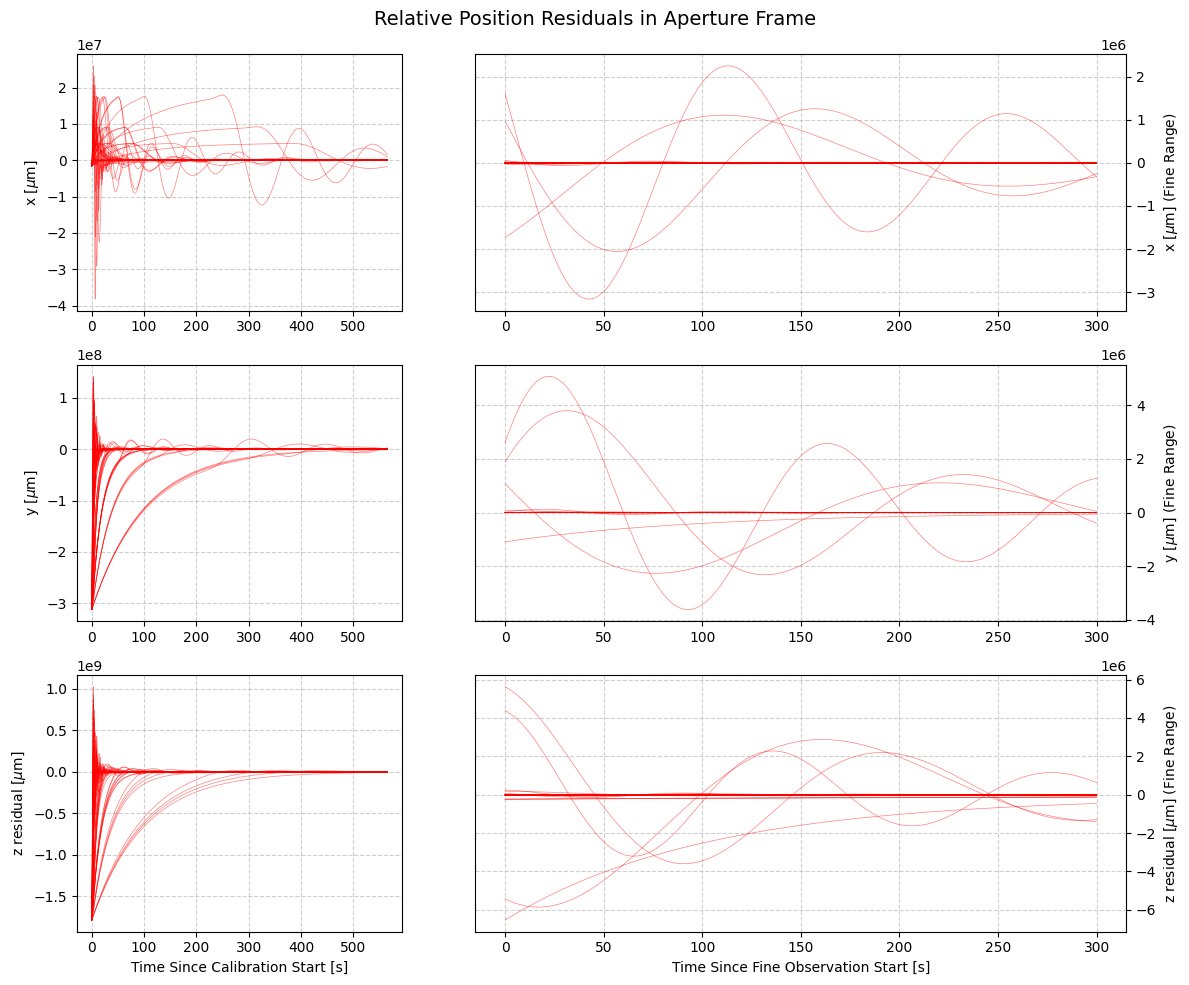

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

coord_letter = ["x", "y", "z"]

alpha_lines = 0.5
current_focal = 5000.0

rel_pos_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
rel_pos_fig.suptitle("Relative Position Residuals in Aperture Frame", fontsize=14)

rel_pos_ax = []

for row in range(3):
    ax_cal = rel_pos_fig.add_subplot(gs[row, 0])
    ax_fine = rel_pos_fig.add_subplot(gs[row, 1])

    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")

    rel_pos_ax.append((ax_cal, ax_fine))

rel_pos_ax[2][0].set_xlabel("Time Since Calibration Start [s]")
rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(len(coord_letter)):
    label = coord_letter[coord]
    if coord == 2:
        label = "z residual"

    rel_pos_ax[coord][0].set_ylabel(f"{label} [$\\mu$m]")
    rel_pos_ax[coord][1].set_ylabel(f"{label} [$\\mu$m] (Fine Range)")
    rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

# Loop over all simulation runs and their parameters together
for i, (kp, kd, ki) in enumerate(zip(kp_vals, kd_vals, ki_vals)):
    t_eng = eng_times[i]
    rel = rel_pos_B[i]

    phase_i = np.array(phase[i], dtype=str)

    cal_idx = np.where(phase_i == "Calibration")[0]
    fine_idx = np.where(phase_i == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = full_times[i][cal_idx[0]], full_times[i][cal_idx[-1]]
        cal_mask = (t_eng >= cal_start) & (t_eng <= cal_end)
    else:
        cal_mask = np.zeros_like(t_eng, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = full_times[i][fine_idx[0]], full_times[i][fine_idx[-1]]
        fine_mask = (t_eng >= fine_start) & (t_eng <= fine_end)
    else:
        fine_mask = np.zeros_like(t_eng, dtype=bool)

    cal_t = t_eng[cal_mask]
    cal_rel = rel[cal_mask]

    fine_t = t_eng[fine_mask]
    fine_rel = rel[fine_mask]

    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(len(coord_letter)):
        cal_vals = cal_rel[:, coord] if len(cal_rel) > 0 else np.array([])
        fine_vals = fine_rel[:, coord] if len(fine_rel) > 0 else np.array([])

        if coord == 2:
            cal_vals = cal_vals - current_focal
            fine_vals = fine_vals - current_focal

        if len(cal_t) > 0 and len(cal_vals) > 0:
            rel_pos_ax[coord][0].plot(
                cal_t, cal_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

        if len(fine_t) > 0 and len(fine_vals) > 0:
            rel_pos_ax[coord][1].plot(
                fine_t, fine_vals * 1e6,
                linewidth=0.5, color="red", alpha=alpha_lines
            )

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)

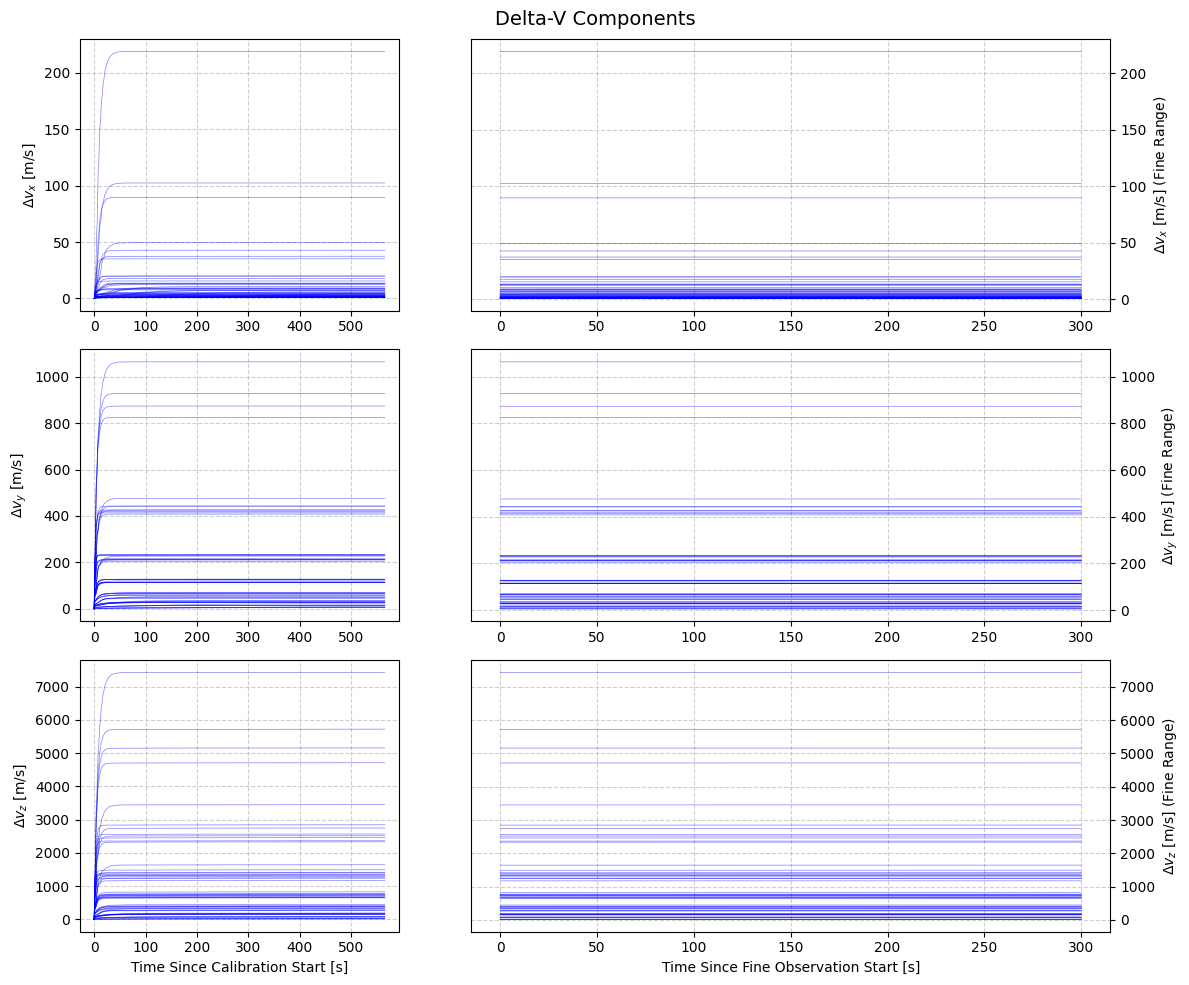

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

coord_letter = ["x", "y", "z"]

alpha_lines = 0.5

dv_fig = plt.figure(figsize=(12, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=dv_fig)
dv_fig.suptitle("Delta-V Components", fontsize=14)

dv_ax = []

for row in range(3):
    ax_cal = dv_fig.add_subplot(gs[row, 0])
    ax_fine = dv_fig.add_subplot(gs[row, 1])

    ax_fine.yaxis.tick_right()
    ax_fine.yaxis.set_label_position("right")

    dv_ax.append((ax_cal, ax_fine))

dv_ax[2][0].set_xlabel("Time Since Calibration Start [s]")
dv_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

for coord in range(len(coord_letter)):
    label = coord_letter[coord]
    dv_ax[coord][0].set_ylabel(f"$\\Delta v_{label}$ [m/s]")
    dv_ax[coord][1].set_ylabel(f"$\\Delta v_{label}$ [m/s] (Fine Range)")
    dv_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
    dv_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

# Loop over all simulation runs
for i, (kp, kd, ki) in enumerate(zip(kp_vals, kd_vals, ki_vals)):
    t = full_times[i]          # matches phase and dv_xyz length
    dv_run = dv_xyz[i]         # shape: (N, 3)
    phase_i = np.array(phase[i], dtype=str)

    cal_idx = np.where(phase_i == "Calibration")[0]
    fine_idx = np.where(phase_i == "Fine Observation")[0]

    if len(cal_idx) > 0:
        cal_start, cal_end = t[cal_idx[0]], t[cal_idx[-1]]
        cal_mask = (t >= cal_start) & (t <= cal_end)
    else:
        cal_mask = np.zeros_like(t, dtype=bool)

    if len(fine_idx) > 0:
        fine_start, fine_end = t[fine_idx[0]], t[fine_idx[-1]]
        fine_mask = (t >= fine_start) & (t <= fine_end)
    else:
        fine_mask = np.zeros_like(t, dtype=bool)

    cal_t = t[cal_mask]
    cal_dv = dv_run[cal_mask]

    fine_t = t[fine_mask]
    fine_dv = dv_run[fine_mask]

    if len(cal_t) > 0:
        cal_t = cal_t - cal_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    for coord in range(3):
        cal_vals = cal_dv[:, coord] if len(cal_dv) > 0 else np.array([])
        fine_vals = fine_dv[:, coord] if len(fine_dv) > 0 else np.array([])

        if len(cal_t) > 0 and len(cal_vals) > 0:
            dv_ax[coord][0].plot(
                cal_t, cal_vals,
                linewidth=0.5, color="blue", alpha=alpha_lines
            )

        if len(fine_t) > 0 and len(fine_vals) > 0:
            dv_ax[coord][1].plot(
                fine_t, fine_vals,
                linewidth=0.5, color="blue", alpha=alpha_lines
            )

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)

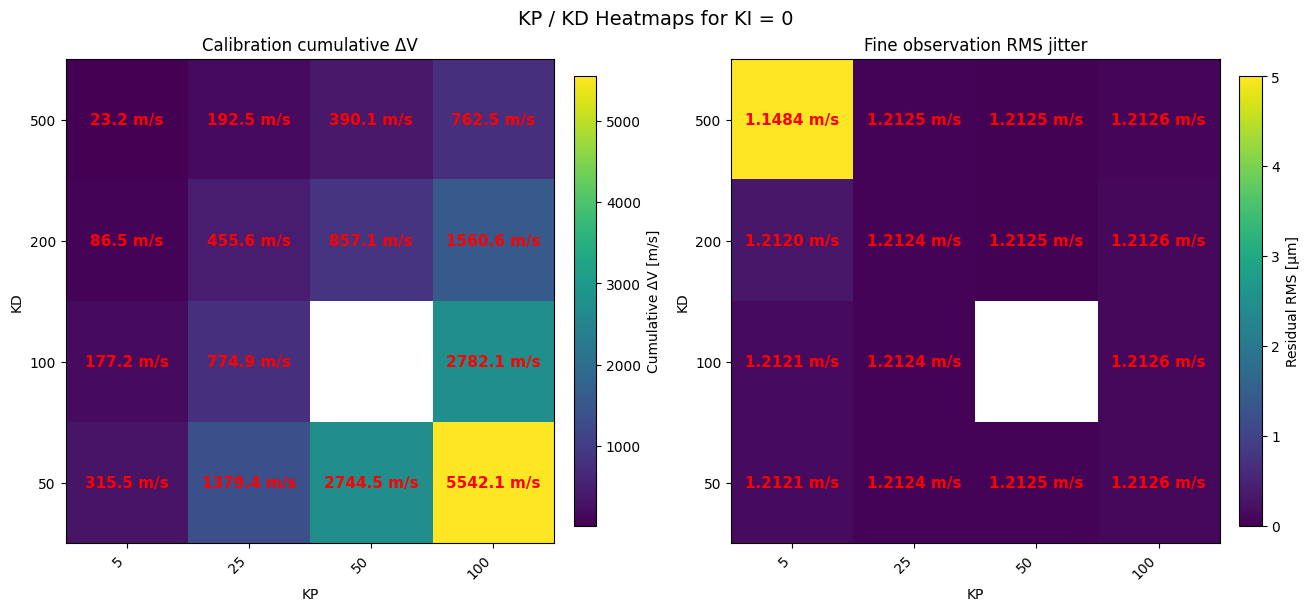

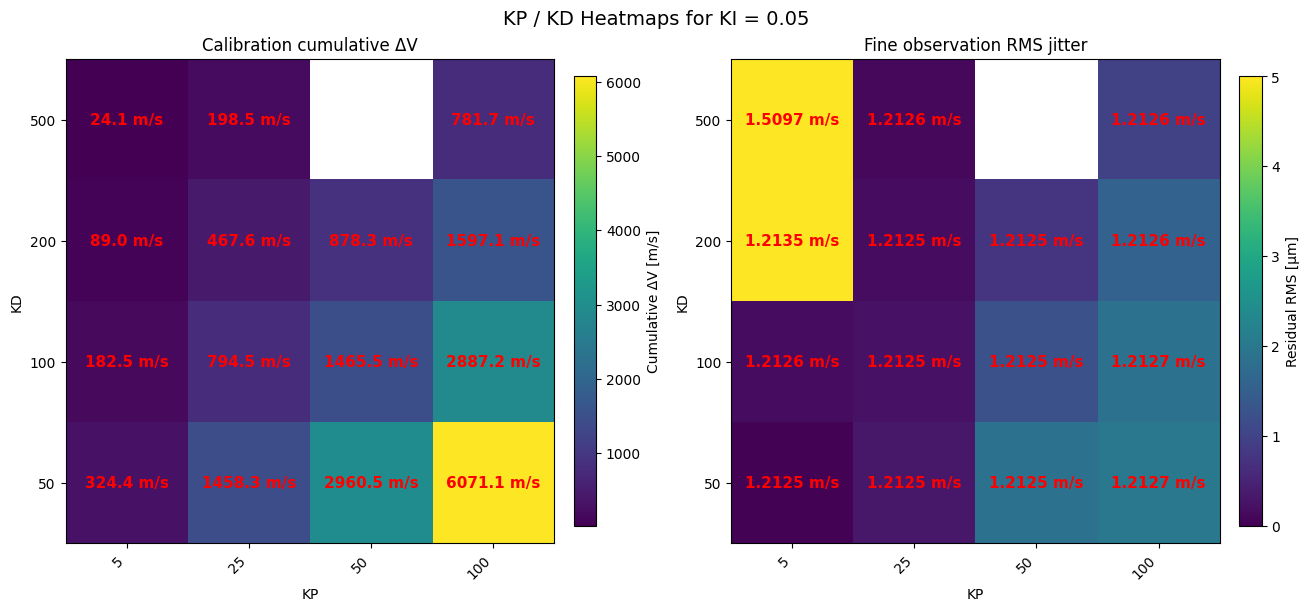

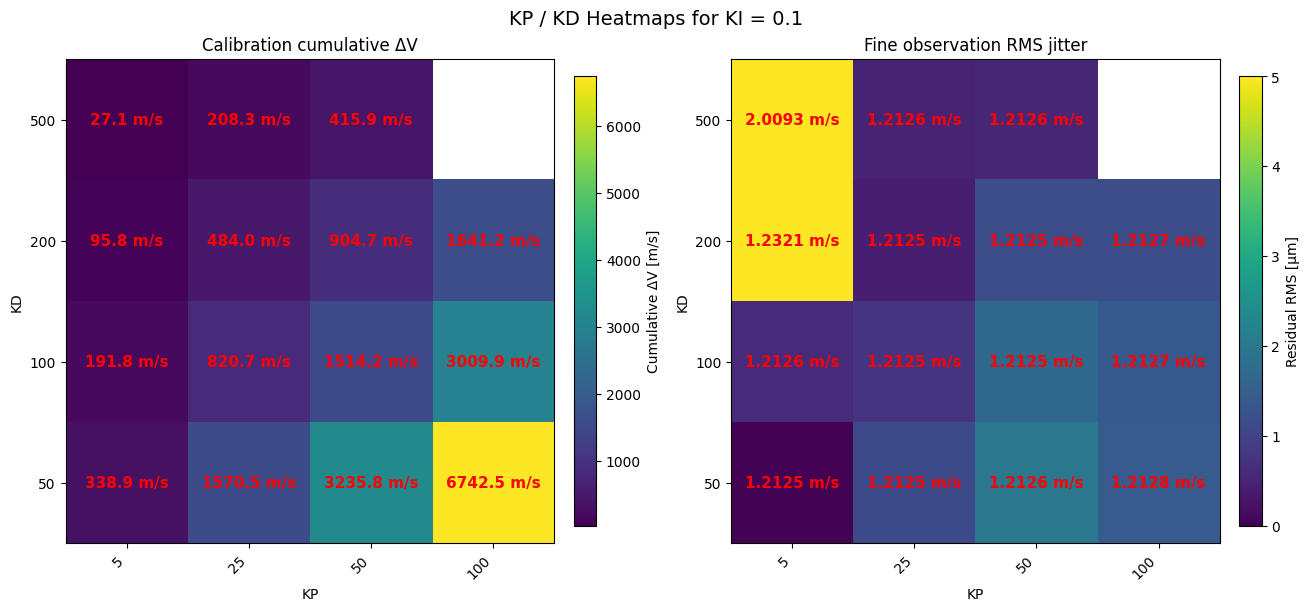

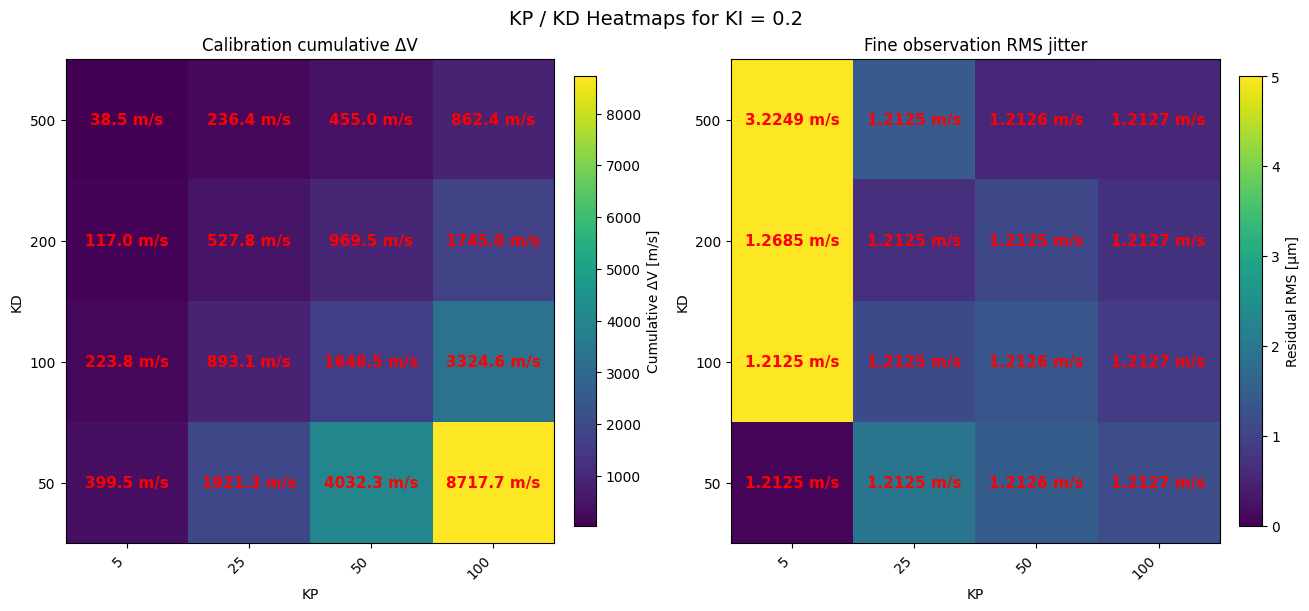

In [10]:
def final_cumulative_dv(run_idx, phase_name):
    dv = np.asarray(dv_xyz[run_idx])
    ph = np.asarray(phase[run_idx], dtype=str)

    idx = np.where(ph == phase_name)[0]
    if idx.size == 0:
        return np.nan

    dv_phase = dv[idx[0] : idx[-1] + 1]
    if dv_phase.size == 0:
        return np.nan

    final_dv = dv_phase[-1]
    return np.nansum(np.abs(final_dv))


def final_dv_vector(run_idx, phase_name):
    """
    Return the final cumulative delta-V vector at the end of a phase.
    """
    dv = np.asarray(dv_xyz[run_idx])
    ph = np.asarray(phase[run_idx], dtype=str)

    idx = np.where(ph == phase_name)[0]
    if idx.size == 0:
        return None

    dv_phase = dv[idx[0] : idx[-1] + 1]
    if dv_phase.size == 0:
        return None

    return dv_phase[-1]


def phase_delta_v_increment(run_idx, start_phase_name, end_phase_name):
    """
    Delta-V burned during end_phase_name, measured as:
      final cumulative vector at end_phase - final cumulative vector at start_phase
    and summed over axes with abs() so signs do not cancel.
    """
    dv_start = final_dv_vector(run_idx, start_phase_name)
    dv_end = final_dv_vector(run_idx, end_phase_name)

    if dv_end is None:
        return np.nan

    if dv_start is None:
        return np.nansum(np.abs(dv_end))

    return np.nansum(np.abs(dv_end - dv_start))


def detrended_rms_savgol(t, y, smooth_frac=0.10, polyorder=2):
    from scipy.signal import savgol_filter

    t = np.asarray(t)
    y = np.asarray(y, dtype=float)

    if y.size < 5:
        return np.nan

    n = y.size
    win = max(5, int(round(n * smooth_frac)))
    if win % 2 == 0:
        win += 1

    if win >= n:
        win = n - 1 if (n - 1) % 2 == 1 else n - 2

    if win < 3:
        resid = y - np.nanmean(y)
        return np.sqrt(np.nanmean(resid**2))

    if win <= polyorder:
        polyorder = max(1, win - 1)

    baseline = savgol_filter(y, window_length=win, polyorder=polyorder, mode="interp")
    resid = y - baseline
    return np.sqrt(np.nanmean(resid**2))


def fine_observation_jitter_rms(run_idx, phase_name, smooth_frac=0.10):
    t_full = np.asarray(full_times[run_idx])
    t_eng = np.asarray(eng_times[run_idx])
    rel = np.asarray(rel_pos_B[run_idx])
    ph = np.asarray(phase[run_idx], dtype=str)

    idx = np.where(ph == phase_name)[0]
    if idx.size == 0:
        return np.nan

    phase_start = t_full[idx[0]]
    phase_end = t_full[idx[-1]]

    phase_mask = (t_eng >= phase_start) & (t_eng <= phase_end)
    t_phase = t_eng[phase_mask]
    rel_phase = rel[phase_mask]

    if t_phase.size < 5:
        return np.nan

    t_phase = t_phase - t_phase[0]

    axis_rms = []

    for j in range(3):
        y = rel_phase[:, j].copy()
        if j == 2:
            y = y - current_focal

        rms_j = detrended_rms_savgol(t_phase, y, smooth_frac=smooth_frac)
        axis_rms.append(rms_j)

    axis_rms = np.asarray(axis_rms)
    if np.all(np.isnan(axis_rms)):
        return np.nan

    return np.sqrt(np.nanmean(axis_rms**2)) * 1e6  # µm


def plot_heatmap(ax, data, texts, title, kp_unique, kd_unique, cbar_label):
    masked = np.ma.masked_invalid(data)

    if "RMS" in title:
        im = ax.imshow(masked, origin="lower", aspect="auto", vmin=0, vmax=5)
    else:
        im = ax.imshow(masked, origin="lower", aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("KP")
    ax.set_ylabel("KD")

    ax.set_xticks(np.arange(len(kp_unique)))
    ax.set_xticklabels([f"{v:g}" for v in kp_unique], rotation=45, ha="right")

    ax.set_yticks(np.arange(len(kd_unique)))
    ax.set_yticklabels([f"{v:g}" for v in kd_unique])

    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            if np.isnan(data[r, c]):
                continue
            ax.text(
                c, r, texts[r, c],
                ha="center", va="center",
                fontsize=11,
                color="red",
                fontweight="bold"
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

    return im


kp_unique = sorted({round(v, 12) for v in kp_vals})
kd_unique = sorted({round(v, 12) for v in kd_vals})
ki_unique = sorted({round(v, 12) for v in ki_vals})

kp_to_col = {v: j for j, v in enumerate(kp_unique)}
kd_to_row = {v: i for i, v in enumerate(kd_unique)}

for ki_target in ki_unique:
    run_ids = [i for i, ki in enumerate(ki_vals) if np.isclose(ki, ki_target)]

    dv_map = np.full((len(kd_unique), len(kp_unique)), np.nan)
    rms_map = np.full_like(dv_map, np.nan)

    dv_text = np.full(dv_map.shape, "", dtype=object)
    fine_dv_text = np.full(dv_map.shape, "", dtype=object)

    for i in run_ids:
        kp_key = round(kp_vals[i], 12)
        kd_key = round(kd_vals[i], 12)

        if kp_key not in kp_to_col or kd_key not in kd_to_row:
            continue

        c = kp_to_col[kp_key]
        r = kd_to_row[kd_key]

        cal_dv = final_cumulative_dv(i, "Calibration")
        fine_rms = fine_observation_jitter_rms(i, "Fine Observation")
        fine_dv = phase_delta_v_increment(i, "Calibration", "Fine Observation")

        dv_map[r, c] = cal_dv
        rms_map[r, c] = fine_rms

        dv_text[r, c] = f"{cal_dv:.1f} m/s" if np.isfinite(cal_dv) else "NA"
        fine_dv_text[r, c] = f"{fine_dv:.4f} m/s" if np.isfinite(fine_dv) else "NA"

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    fig.suptitle(f"KP / KD Heatmaps for KI = {ki_target:g}", fontsize=14)

    # LEFT: Calibration delta-V color + delta-V text
    plot_heatmap(
        axes[0],
        dv_map,
        dv_text,
        "Calibration cumulative ΔV",
        kp_unique,
        kd_unique,
        "Cumulative ΔV [m/s]"
    )

    # RIGHT: Fine observation RMS color + fine delta-V text
    plot_heatmap(
        axes[1],
        rms_map,
        fine_dv_text,
        "Fine observation RMS jitter",
        kp_unique,
        kd_unique,
        "Residual RMS [µm]"
    )

    fig.savefig(f"heatmaps_ki_{ki_target:g}.png", dpi=300, bbox_inches="tight")
    plt.show()